# 53 Boost 2 — XGBoost, GradientBoosting y AdaBoost

Tres algoritmos de boosting sobre `sale` y `rent` prediciendo `log_precio`.

- Features fijas definidas manualmente (ya numéricas/binarias)
- Municipios con < 10 observaciones se unifican en `municipio_otro`
- Split 80/20 train-test, CV de 5 folds
- Primero modelo base (hiperparámetros por defecto) y luego GridSearchCV

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    print("AVISO: optuna no disponible — instala con: pip install optuna")
    OPTUNA_AVAILABLE = False


pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ─────────────────────────────────────────────────────────────
RANDOM_STATE      = 42
TEST_SIZE         = 0.20
TARGET_COL        = "log_precio"
CV_FOLDS          = 5

# ── Rutas ─────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale_idealistaAPI.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent_idealistaAPI.csv",
}

print("Datasets:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale_idealistaAPI.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent_idealistaAPI.csv


In [9]:
# ── Features ──────────────────────────────────────────────────────────────────
# Superconjunto completo alineado con el híbrido (NB54).
# Las features se entregan todas al modelo; la selección se realiza mediante
# Optuna + importancia de variables en la sección "Modelo Definitivo".
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "latitud",
    "longitud",
    "planta_num",                          # entero limpio (parse_planta en gold)
    "es_exterior_piso",                    # es_exterior × is_piso (gold)
    "tiene_ascensor_piso",                 # tiene_ascensor × is_piso (gold)
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",
    "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    "interaccion_planta_sin_ascensor_piso",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente desde el gold file
]

# ── Hiperparámetros: grids de búsqueda ────────────────────────────────────────
PARAM_GRID_XGB = {
    "n_estimators":     [200, 400],
    "max_depth":        [3, 4, 5],
    "learning_rate":    [0.05, 0.1],
    "subsample":        [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "min_child_weight": [3, 5],
    "reg_lambda":       [1, 5],
}

PARAM_GRID_GBR = {
    "n_estimators":    [200, 400],
    "max_depth":       [3, 4, 5],
    "learning_rate":   [0.05, 0.1],
    "subsample":       [0.7, 0.9],
    "min_samples_leaf": [5, 10],
}

PARAM_GRID_ADA = {
    "n_estimators":         [100, 200, 400],
    "learning_rate":        [0.5, 1.0, 1.5],
    "estimator__max_depth": [3, 5, 7],
}

In [10]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def get_metrics(y_real, y_pred) -> pd.DataFrame:
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(mse,  5)],
        "RMSE": [round(rmse, 5)],
        "MAE":  [round(mae,  5)],
        "R2":   [round(r2,   5)],
        "MAPE": [round(mape, 5)],
    })


def collapse_rare_municipios(df: pd.DataFrame, muni_cols=None, min_obs: int = 10) -> tuple:
    """Función mantenida por compatibilidad. El colapso ya se realizó en el gold notebook.
    Devuelve el df sin cambios y todas las columnas municipio_* disponibles."""
    final_muni_cols = sorted([c for c in df.columns if c.startswith("municipio_")])
    return df, final_muni_cols


def prepare_X(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    """Selecciona features disponibles, imputa nulos con mediana."""
    cols = [c for c in feature_cols if c in df.columns]
    X = df[cols].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X


def plot_diagnostics(y_test, pred_test, title_prefix: str):
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=15)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{title_prefix} | Real vs Predicho")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")

    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix} | Residuos (test)")
    ax.set_xlabel("Residuo (real − predicho)")
    ax.set_ylabel("Frecuencia")

    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix} | Q-Q plot residuos")

    plt.tight_layout()
    plt.show()


def plot_feature_importance(importances: np.ndarray, feature_names: list, title: str, top_n: int = 15):
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    return fi


def run_base_model(model, X_train, X_test, y_train, y_test, model_name: str, dataset_name: str):
    """Entrena modelo base y muestra métricas."""
    print(f"\n--- {model_name} | Modelo base ---")
    model.fit(X_train, y_train)
    m_train = get_metrics(y_train, model.predict(X_train))
    m_test  = get_metrics(y_test,  model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return model, m_train, m_test


def run_grid_search(estimator, param_grid, X_train, X_test, y_train, y_test, model_name: str, dataset_name: str):
    """Ejecuta GridSearchCV y muestra métricas del mejor modelo."""
    n_comb = int(np.prod([len(v) for v in param_grid.values()]))
    print(f"\n--- {model_name} | GridSearch ({n_comb} combinaciones, CV={CV_FOLDS}) ---")
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    cv_rmse     = float(-gs.best_score_)
    best_model  = gs.best_estimator_
    print(f"  Mejores params: {gs.best_params_}")
    print(f"  CV RMSE (mejor): {cv_rmse:.5f}")

    m_train = get_metrics(y_train, best_model.predict(X_train))
    m_test  = get_metrics(y_test,  best_model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        pd.DataFrame({"split": ["CV"], "MSE": [None], "RMSE": [round(cv_rmse, 5)], "MAE": [None], "R2": [None], "MAPE": [None]}),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return best_model, gs, m_train, m_test, cv_rmse


print("Funciones cargadas.")

Funciones cargadas.



DATASET: SALE
Filas cargadas: 2700
Features finales: 52 | Filas: 2700
Train: 2160 | Test: 540

────────────────────────────────────────────────────────────
XGBOOST
────────────────────────────────────────────────────────────

--- XGBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.00209 0.04575 0.03233 0.99395 0.00258
 test 0.07910 0.28124 0.19363 0.78063 0.01562
  Sobreajuste → ratio RMSE test/train: 6.1473 | delta R2: 0.2133


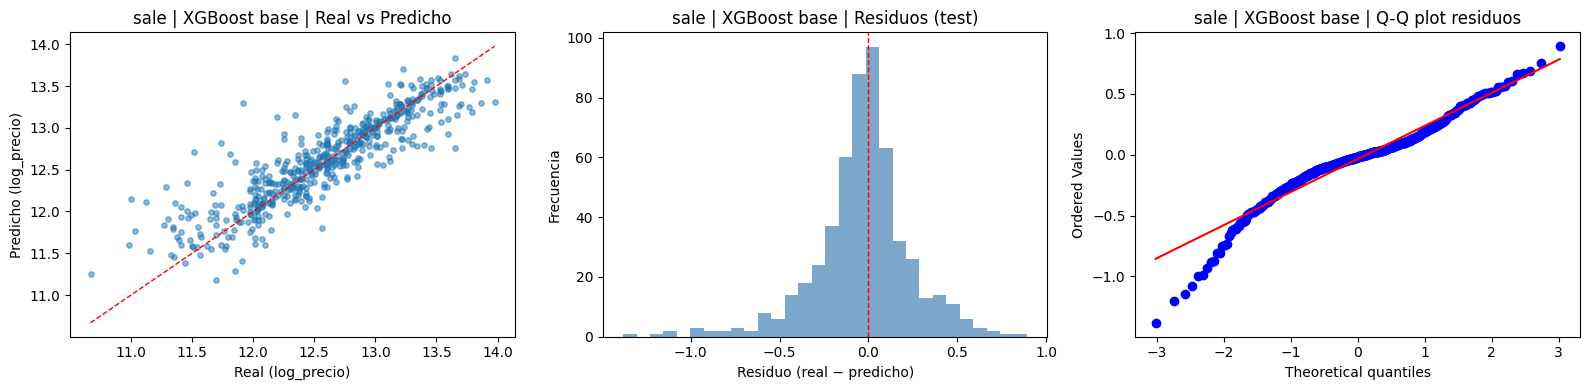

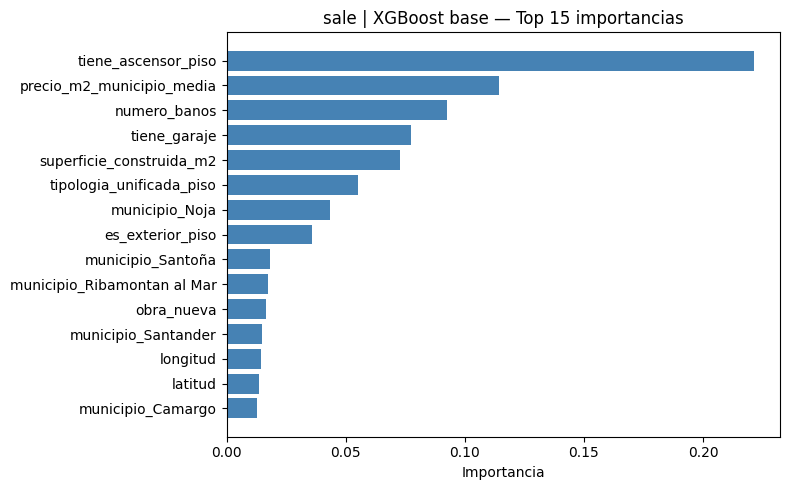


--- XGBoost | GridSearch (192 combinaciones, CV=5) ---
  Mejores params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 400, 'reg_lambda': 1, 'subsample': 0.9}
  CV RMSE (mejor): 0.27213
split     MSE    RMSE     MAE      R2    MAPE
train 0.01390 0.11788 0.08528 0.95985 0.00682
   CV     NaN 0.27213     NaN     NaN     NaN
 test 0.07554 0.27484 0.18944 0.79050 0.01528
  Sobreajuste → ratio RMSE test/train: 2.3315 | delta R2: 0.1694


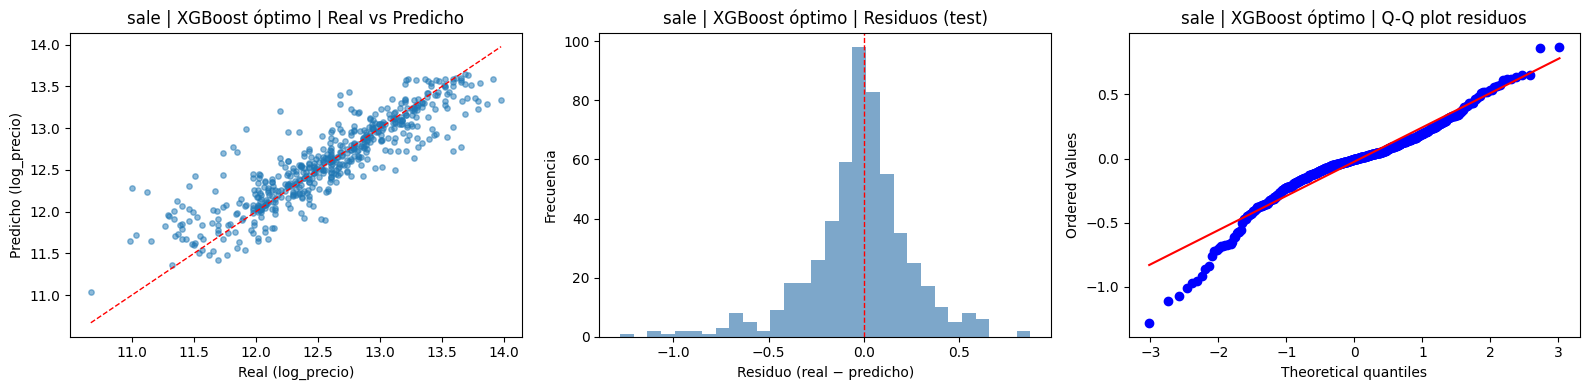

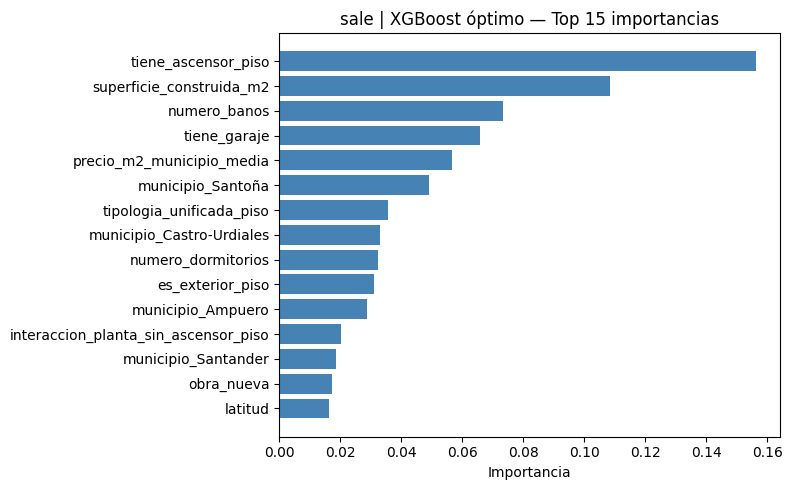


────────────────────────────────────────────────────────────
GRADIENT BOOSTING (sklearn)
────────────────────────────────────────────────────────────

--- GBR | Modelo base ---
split     MSE    RMSE     MAE     R2    MAPE
train 0.05745 0.23968 0.17914 0.8340 0.01435
 test 0.09432 0.30712 0.22121 0.7384 0.01783
  Sobreajuste → ratio RMSE test/train: 1.2814 | delta R2: 0.0956


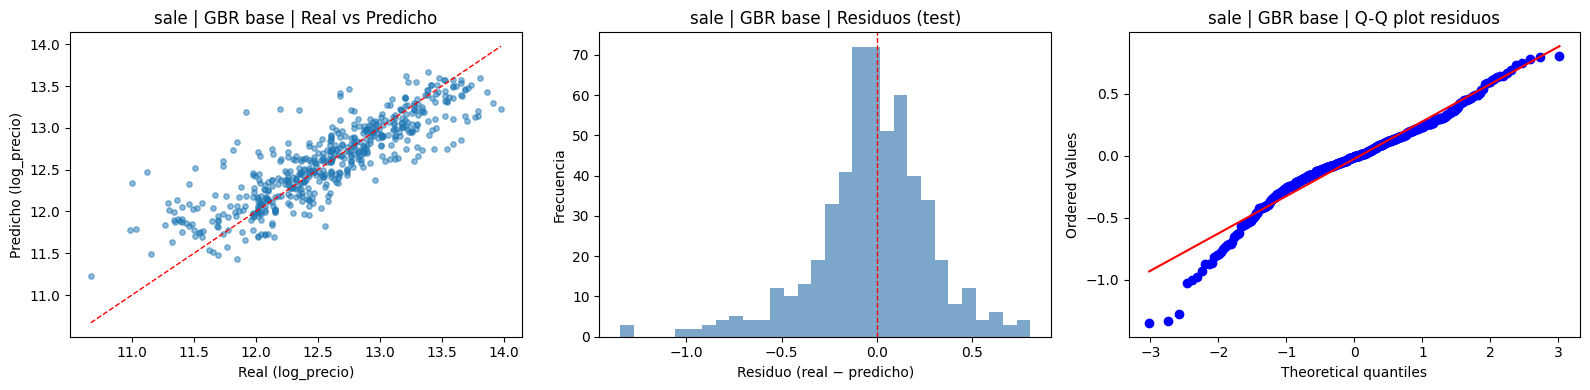

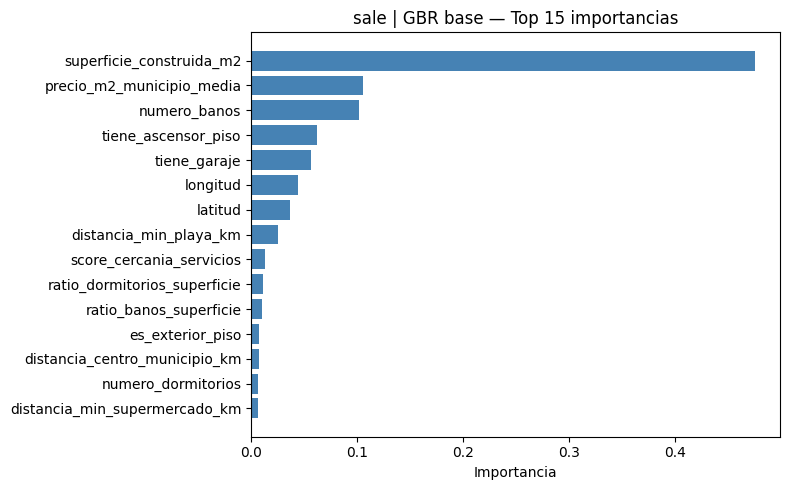


--- GBR | GridSearch (48 combinaciones, CV=5) ---
  Mejores params: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 400, 'subsample': 0.7}
  CV RMSE (mejor): 0.27388
split     MSE    RMSE     MAE      R2    MAPE
train 0.01345 0.11597 0.08525 0.96114 0.00682
   CV     NaN 0.27388     NaN     NaN     NaN
 test 0.07704 0.27757 0.19180 0.78632 0.01546
  Sobreajuste → ratio RMSE test/train: 2.3935 | delta R2: 0.1748


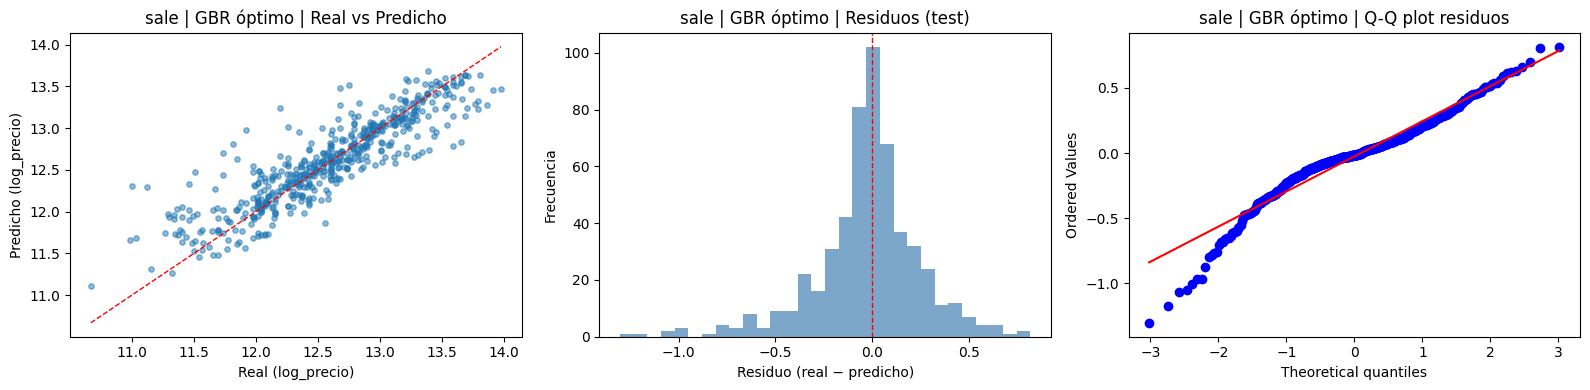

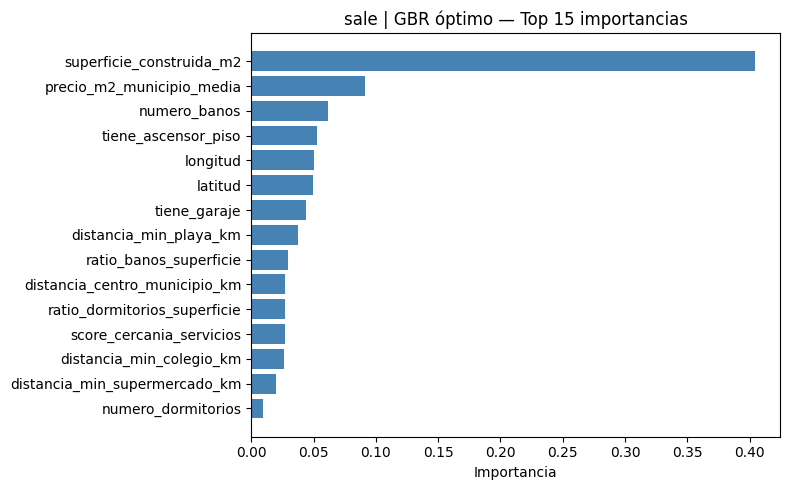


────────────────────────────────────────────────────────────
ADABOOST
────────────────────────────────────────────────────────────

--- AdaBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.10779 0.32832 0.26622 0.68852 0.02119
 test 0.12947 0.35981 0.28607 0.64093 0.02282
  Sobreajuste → ratio RMSE test/train: 1.0959 | delta R2: 0.0476


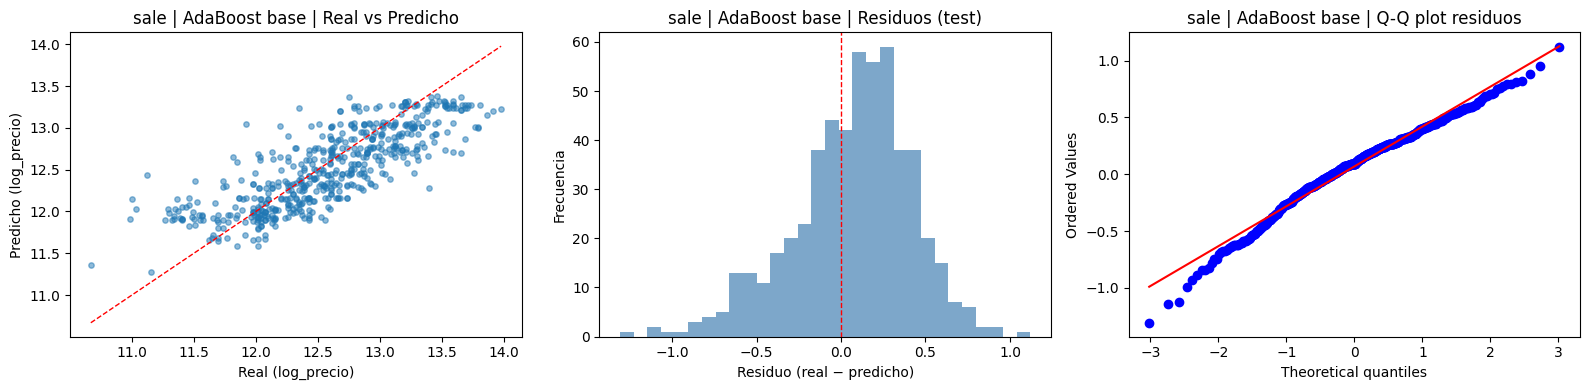

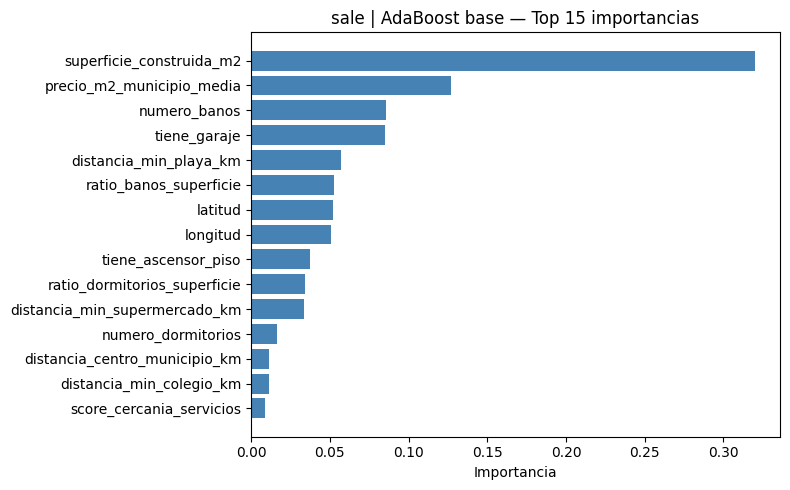


--- AdaBoost | GridSearch (27 combinaciones, CV=5) ---
  Mejores params: {'estimator__max_depth': 7, 'learning_rate': 1.5, 'n_estimators': 400}
  CV RMSE (mejor): 0.28343
split     MSE    RMSE    MAE      R2    MAPE
train 0.02550 0.15968 0.1381 0.92632 0.01099
   CV     NaN 0.28343    NaN     NaN     NaN
 test 0.08338 0.28876 0.2099 0.76874 0.01687
  Sobreajuste → ratio RMSE test/train: 1.8084 | delta R2: 0.1576


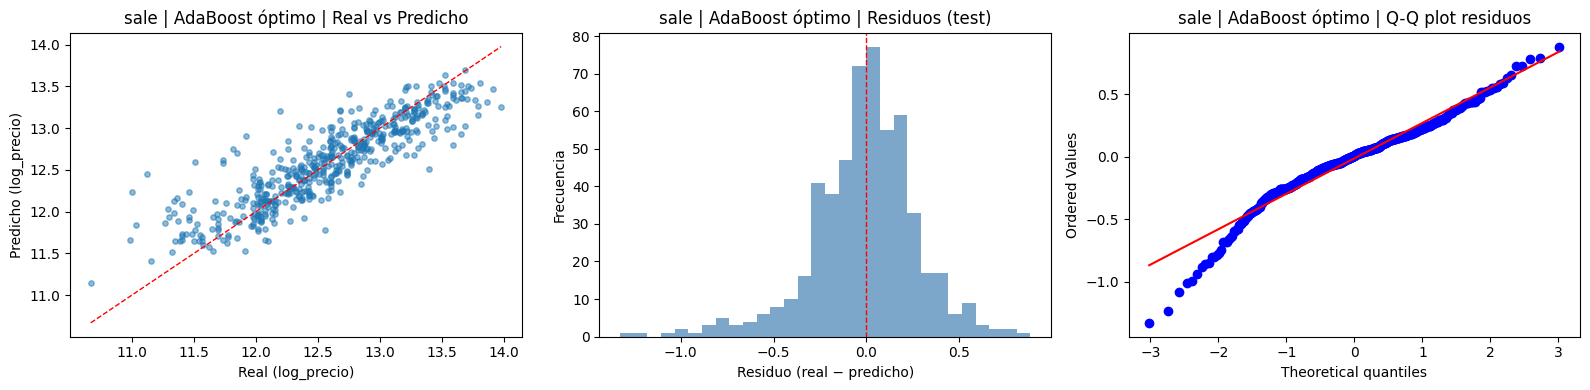

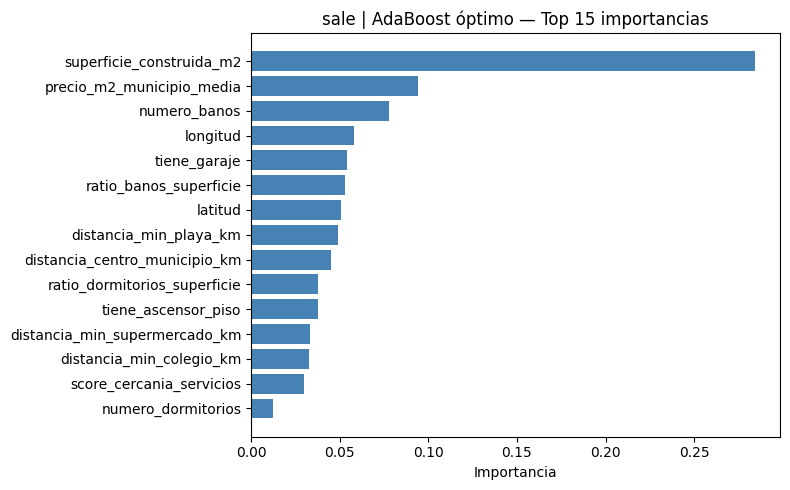


RESUMEN SALE — comparativa modelos
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale  XGBoost   base     0.04575    0.28124   0.99395  0.78063      NaN
   sale  XGBoost optimo     0.11788    0.27484   0.95985  0.79050  0.27213
   sale      GBR   base     0.23968    0.30712   0.83400  0.73840      NaN
   sale      GBR optimo     0.11597    0.27757   0.96114  0.78632  0.27388
   sale AdaBoost   base     0.32832    0.35981   0.68852  0.64093      NaN
   sale AdaBoost optimo     0.15968    0.28876   0.92632  0.76874  0.28343

DATASET: RENT
Filas cargadas: 776
Features finales: 31 | Filas: 776
Train: 620 | Test: 156

────────────────────────────────────────────────────────────
XGBOOST
────────────────────────────────────────────────────────────

--- XGBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.00003 0.00520 0.00355 0.99974 0.00051
 test 0.05488 0.23427 0.16683 0.49432 0.02426
  Sobreajuste → ratio RMSE test/train: 45.0519 

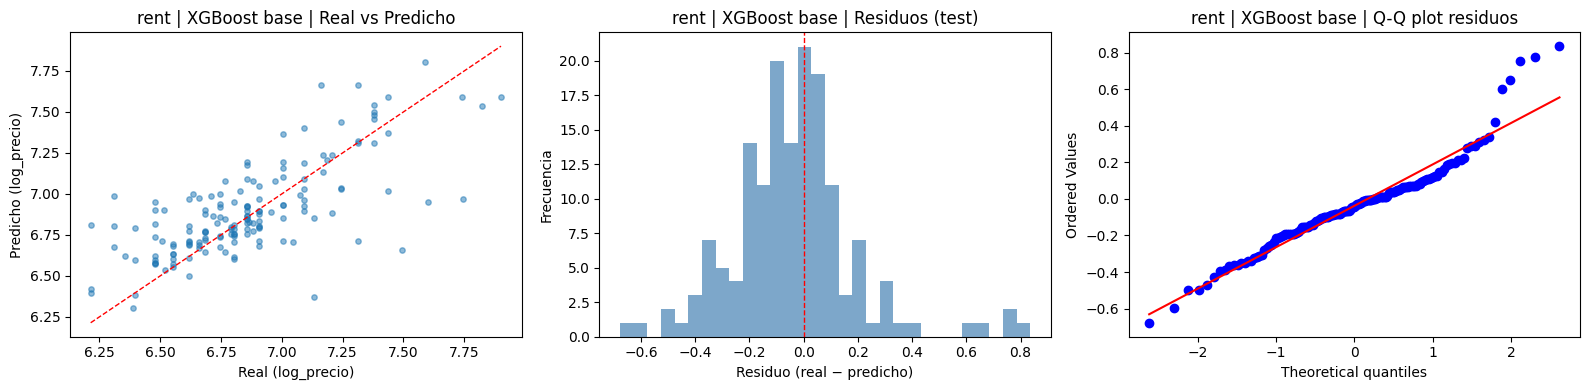

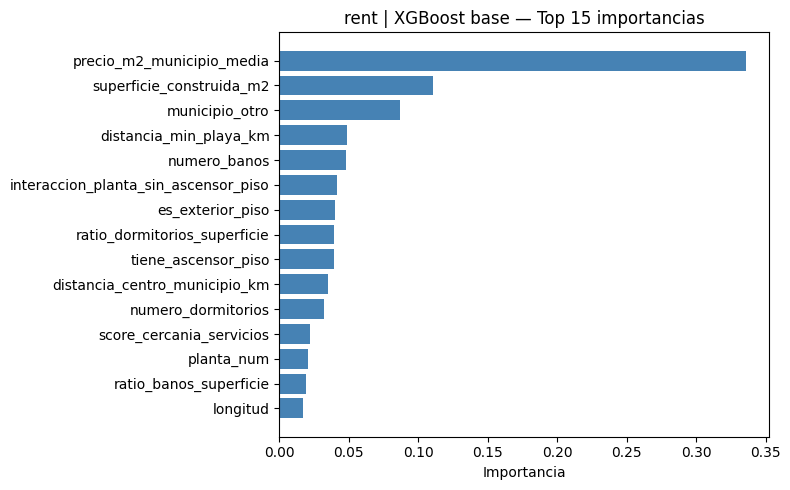


--- XGBoost | GridSearch (192 combinaciones, CV=5) ---
  Mejores params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200, 'reg_lambda': 5, 'subsample': 0.9}
  CV RMSE (mejor): 0.22123
split     MSE    RMSE     MAE      R2    MAPE
train 0.02258 0.15025 0.11032 0.78436 0.01578
   CV     NaN 0.22123     NaN     NaN     NaN
 test 0.05060 0.22494 0.16247 0.53382 0.02361
  Sobreajuste → ratio RMSE test/train: 1.4971 | delta R2: 0.2505


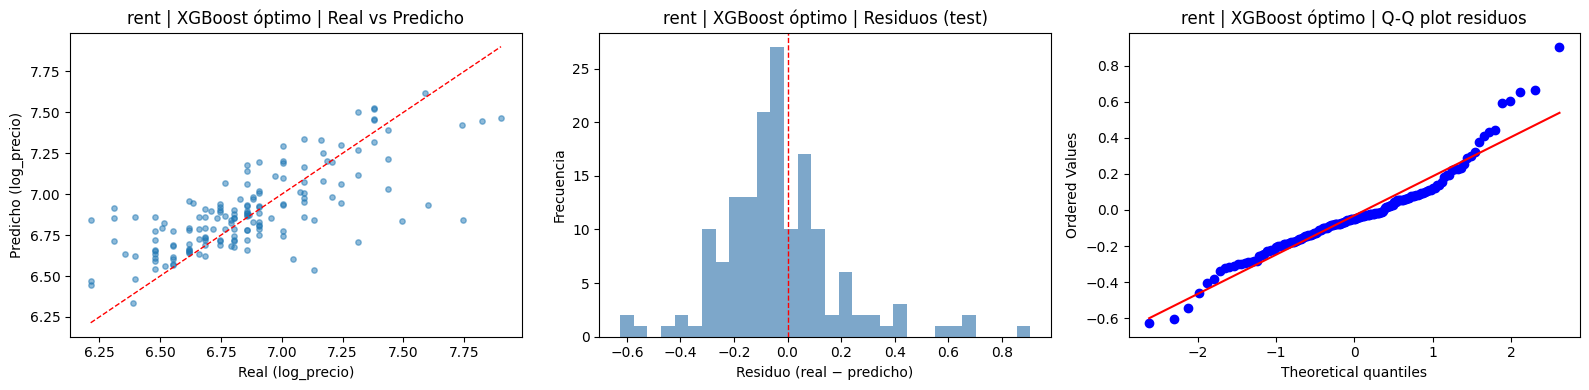

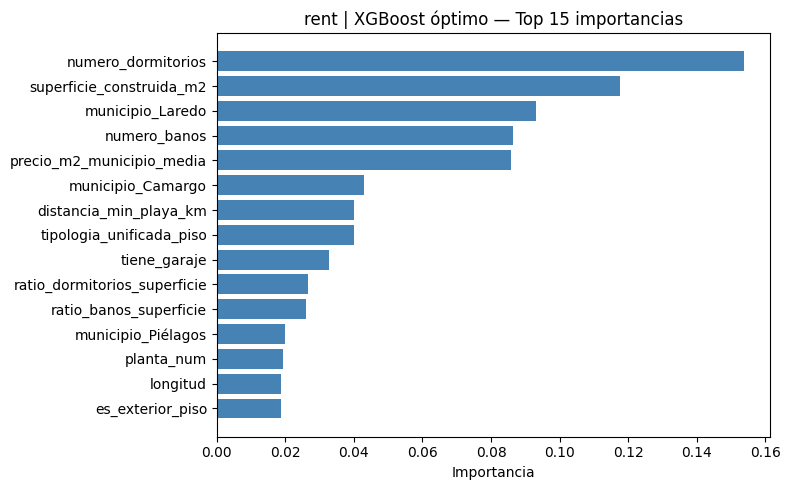


────────────────────────────────────────────────────────────
GRADIENT BOOSTING (sklearn)
────────────────────────────────────────────────────────────

--- GBR | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.01995 0.14126 0.10507 0.80940 0.01504
 test 0.05712 0.23901 0.16751 0.47366 0.02439
  Sobreajuste → ratio RMSE test/train: 1.6920 | delta R2: 0.3357


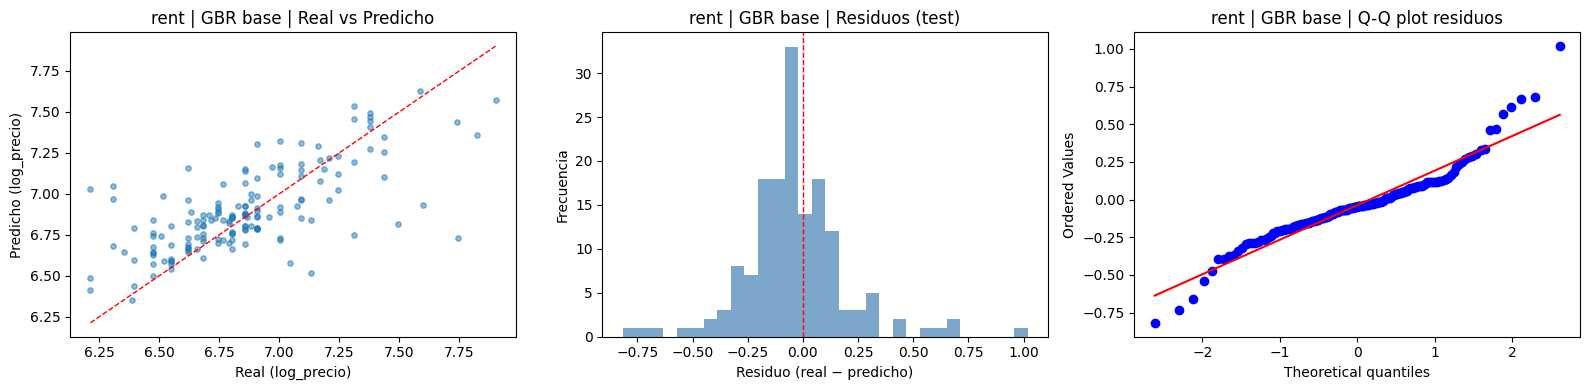

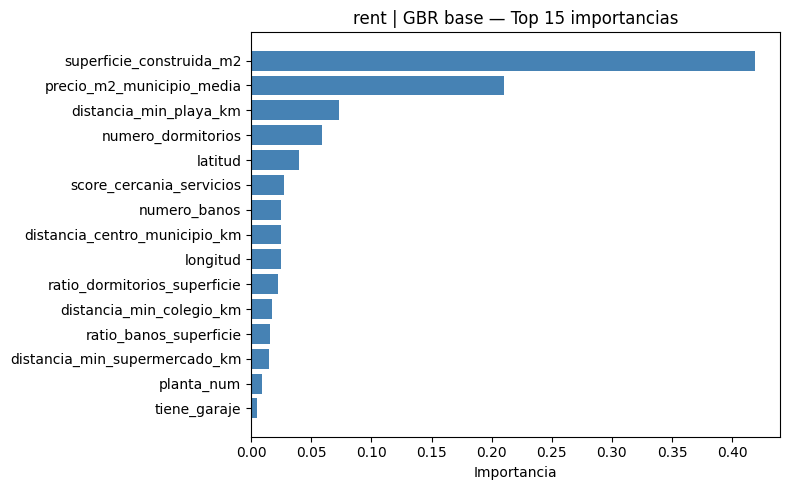


--- GBR | GridSearch (48 combinaciones, CV=5) ---
  Mejores params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 200, 'subsample': 0.7}
  CV RMSE (mejor): 0.22437
split     MSE    RMSE     MAE      R2    MAPE
train 0.02154 0.14678 0.10692 0.79420 0.01529
   CV     NaN 0.22437     NaN     NaN     NaN
 test 0.04878 0.22085 0.15939 0.55058 0.02310
  Sobreajuste → ratio RMSE test/train: 1.5046 | delta R2: 0.2436


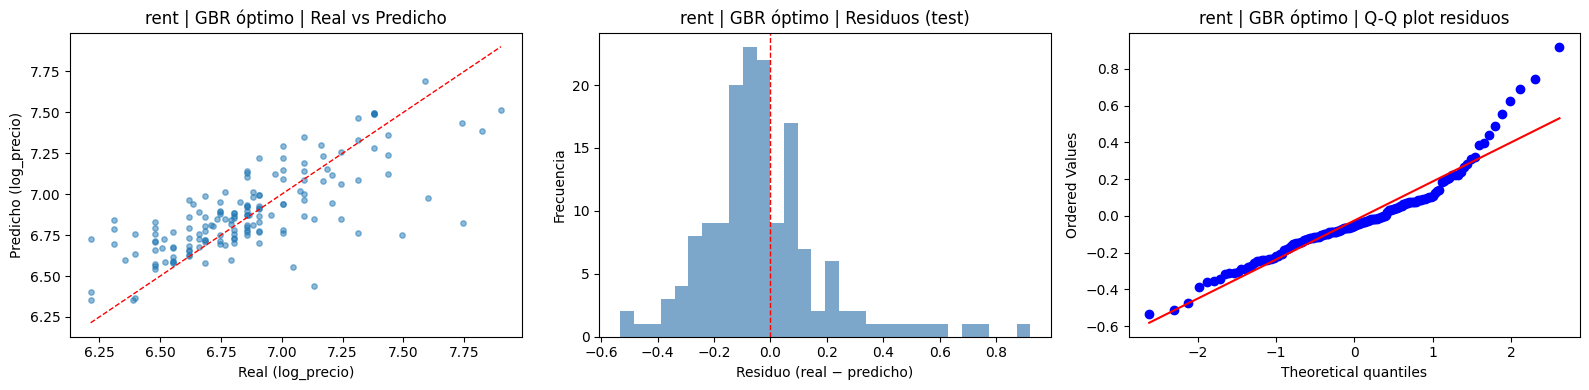

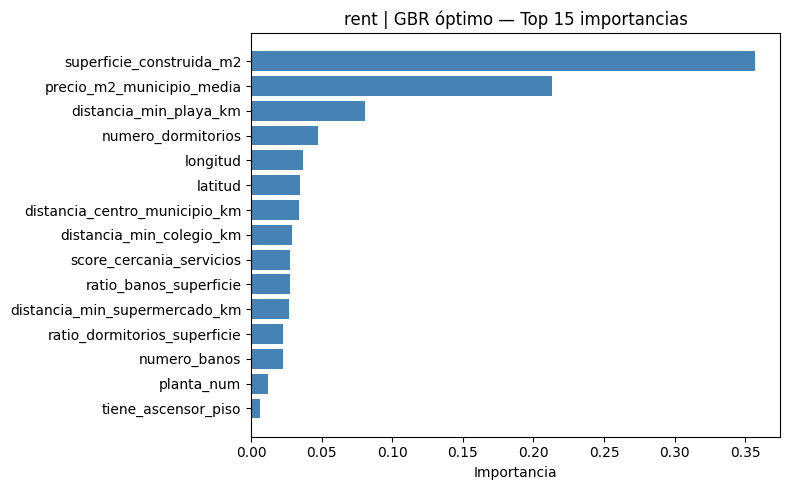


────────────────────────────────────────────────────────────
ADABOOST
────────────────────────────────────────────────────────────

--- AdaBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.05005 0.22373 0.19069 0.52187 0.02762
 test 0.07335 0.27082 0.21747 0.32421 0.03198
  Sobreajuste → ratio RMSE test/train: 1.2105 | delta R2: 0.1977


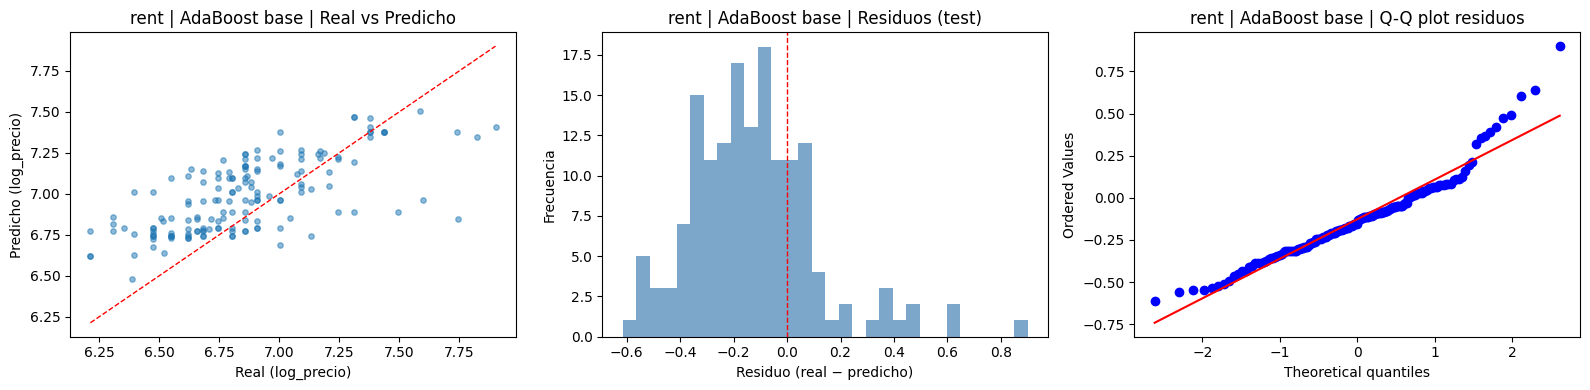

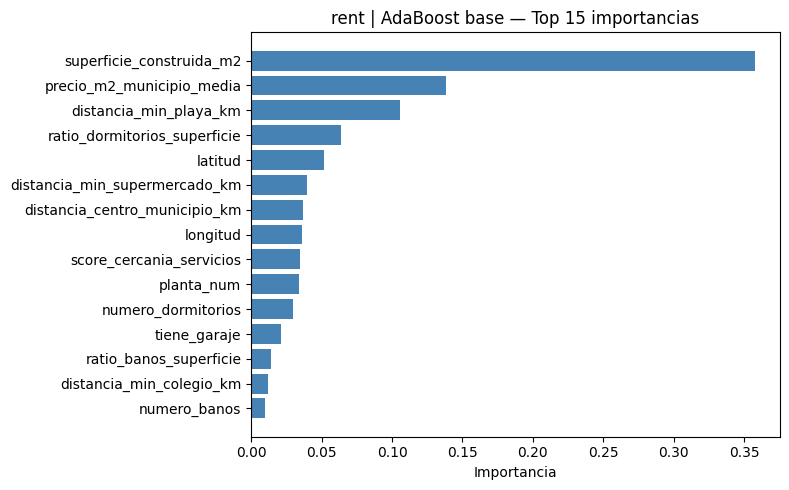


--- AdaBoost | GridSearch (27 combinaciones, CV=5) ---
  Mejores params: {'estimator__max_depth': 7, 'learning_rate': 1.0, 'n_estimators': 200}
  CV RMSE (mejor): 0.22784
split     MSE    RMSE     MAE      R2    MAPE
train 0.00712 0.08436 0.06936 0.93201 0.01008
   CV     NaN 0.22784     NaN     NaN     NaN
 test 0.04740 0.21771 0.16292 0.56329 0.02369
  Sobreajuste → ratio RMSE test/train: 2.5807 | delta R2: 0.3687


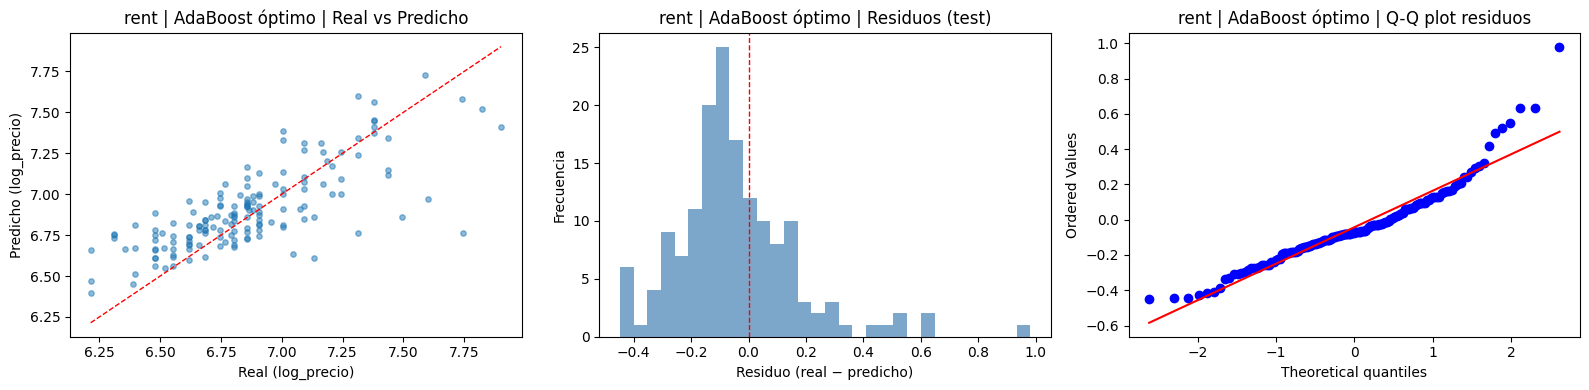

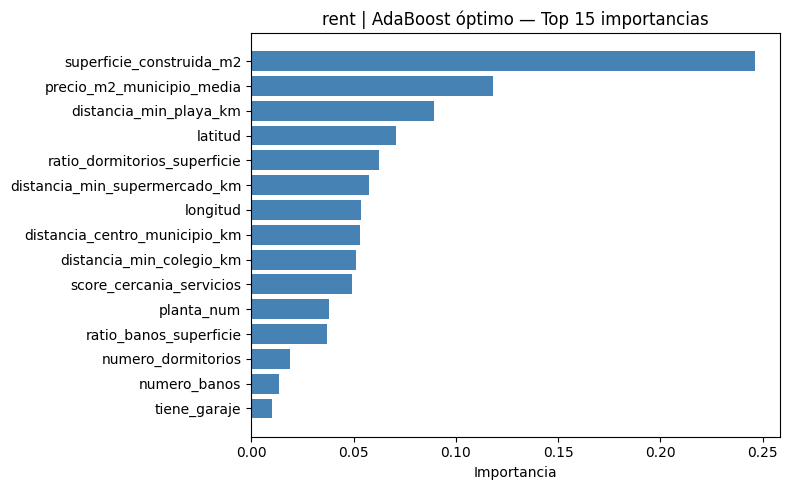


RESUMEN RENT — comparativa modelos
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   rent  XGBoost   base     0.00520    0.23427   0.99974  0.49432      NaN
   rent  XGBoost optimo     0.15025    0.22494   0.78436  0.53382  0.22123
   rent      GBR   base     0.14126    0.23901   0.80940  0.47366      NaN
   rent      GBR optimo     0.14678    0.22085   0.79420  0.55058  0.22437
   rent AdaBoost   base     0.22373    0.27082   0.52187  0.32421      NaN
   rent AdaBoost optimo     0.08436    0.21771   0.93201  0.56329  0.22784

RESUMEN GLOBAL
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale  XGBoost   base     0.04575    0.28124   0.99395  0.78063      NaN
   sale  XGBoost optimo     0.11788    0.27484   0.95985  0.79050  0.27213
   sale      GBR   base     0.23968    0.30712   0.83400  0.73840      NaN
   sale      GBR optimo     0.11597    0.27757   0.96114  0.78632  0.27388
   sale AdaBoost   base     0.32832    0.35981  

,dataset,modelo,fase,train_RMSE,test_RMSE,train_R2,test_R2,cv_RMSE
0,sale,XGBoost,base,0.04575,0.28124,0.99395,0.78063,NaN
1,sale,XGBoost,optimo,0.11788,0.27484,0.95985,0.79050,0.272135
2,sale,GBR,base,0.23968,0.30712,0.83400,0.73840,NaN
3,sale,GBR,optimo,0.11597,0.27757,0.96114,0.78632,0.273883
4,sale,AdaBoost,base,0.32832,0.35981,0.68852,0.64093,NaN
5,sale,AdaBoost,optimo,0.15968,0.28876,0.92632,0.76874,0.283427
6,rent,XGBoost,base,0.00520,0.23427,0.99974,0.49432,NaN
7,rent,XGBoost,optimo,0.15025,0.22494,0.78436,0.53382,0.221228
8,rent,GBR,base,0.14126,0.23901,0.80940,0.47366,NaN
9,rent,GBR,optimo,0.14678,0.22085,0.79420,0.55058,0.224374


In [11]:
# ── Bucle principal: un bloque por dataset ────────────────────────────────────

all_summary_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    # ── Carga ─────────────────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"Filas cargadas: {len(df)}")

    final_muni_cols = sorted([c for c in df.columns if c.startswith("municipio_")])

    # ── Preparar features ─────────────────────────────────────────────────────
    all_feature_cols = BASE_FEATURES + final_muni_cols
    X = prepare_X(df, all_feature_cols)
    y = df[TARGET_COL].reset_index(drop=True)

    # alinear índices tras reset del imputer
    y = df[TARGET_COL].values

    print(f"Features finales: {X.shape[1]} | Filas: {X.shape[0]}")

    # ── Split 80/20 ───────────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    feature_names = X_train.columns.tolist()

    # ══════════════════════════════════════════════════════════════════════════
    # 1. XGBoost
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("XGBOOST")
    print("─" * 60)

    # Base
    xgb_base = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    xgb_base, xgb_base_train, xgb_base_test = run_base_model(
        xgb_base, X_train, X_test, y_train, y_test, "XGBoost", dataset_name
    )
    plot_diagnostics(y_test, xgb_base.predict(X_test), f"{dataset_name} | XGBoost base")
    fi_xgb_base = plot_feature_importance(
        xgb_base.feature_importances_, feature_names,
        f"{dataset_name} | XGBoost base — Top 15 importancias"
    )

    # Grid Search
    xgb_opt, xgb_gs, xgb_opt_train, xgb_opt_test, xgb_cv_rmse = run_grid_search(
        XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
        PARAM_GRID_XGB, X_train, X_test, y_train, y_test, "XGBoost", dataset_name
    )
    plot_diagnostics(y_test, xgb_opt.predict(X_test), f"{dataset_name} | XGBoost óptimo")
    fi_xgb_opt = plot_feature_importance(
        xgb_opt.feature_importances_, feature_names,
        f"{dataset_name} | XGBoost óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 2. GradientBoosting
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("GRADIENT BOOSTING (sklearn)")
    print("─" * 60)

    # Base
    gbr_base = GradientBoostingRegressor(random_state=RANDOM_STATE)
    gbr_base, gbr_base_train, gbr_base_test = run_base_model(
        gbr_base, X_train, X_test, y_train, y_test, "GBR", dataset_name
    )
    plot_diagnostics(y_test, gbr_base.predict(X_test), f"{dataset_name} | GBR base")
    fi_gbr_base = plot_feature_importance(
        gbr_base.feature_importances_, feature_names,
        f"{dataset_name} | GBR base — Top 15 importancias"
    )

    # Grid Search
    gbr_opt, gbr_gs, gbr_opt_train, gbr_opt_test, gbr_cv_rmse = run_grid_search(
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        PARAM_GRID_GBR, X_train, X_test, y_train, y_test, "GBR", dataset_name
    )
    plot_diagnostics(y_test, gbr_opt.predict(X_test), f"{dataset_name} | GBR óptimo")
    fi_gbr_opt = plot_feature_importance(
        gbr_opt.feature_importances_, feature_names,
        f"{dataset_name} | GBR óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 3. AdaBoost
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("ADABOOST")
    print("─" * 60)

    # Base
    ada_base = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3),
        random_state=RANDOM_STATE,
    )
    ada_base, ada_base_train, ada_base_test = run_base_model(
        ada_base, X_train, X_test, y_train, y_test, "AdaBoost", dataset_name
    )
    plot_diagnostics(y_test, ada_base.predict(X_test), f"{dataset_name} | AdaBoost base")
    fi_ada_base = plot_feature_importance(
        ada_base.feature_importances_, feature_names,
        f"{dataset_name} | AdaBoost base — Top 15 importancias"
    )

    # Grid Search
    ada_opt, ada_gs, ada_opt_train, ada_opt_test, ada_cv_rmse = run_grid_search(
        AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=RANDOM_STATE),
        PARAM_GRID_ADA, X_train, X_test, y_train, y_test, "AdaBoost", dataset_name
    )
    plot_diagnostics(y_test, ada_opt.predict(X_test), f"{dataset_name} | AdaBoost óptimo")
    fi_ada_opt = plot_feature_importance(
        ada_opt.feature_importances_, feature_names,
        f"{dataset_name} | AdaBoost óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # Resumen del dataset
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print(f"RESUMEN {dataset_name.upper()} — comparativa modelos")
    print("=" * 60)

    rows = [
        {"dataset": dataset_name, "modelo": "XGBoost",  "fase": "base",
         "train_RMSE": float(xgb_base_train["RMSE"].iloc[0]), "test_RMSE": float(xgb_base_test["RMSE"].iloc[0]),
         "train_R2":   float(xgb_base_train["R2"].iloc[0]),   "test_R2":   float(xgb_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "XGBoost",  "fase": "optimo",
         "train_RMSE": float(xgb_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(xgb_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(xgb_opt_train["R2"].iloc[0]),    "test_R2":   float(xgb_opt_test["R2"].iloc[0]),    "cv_RMSE": xgb_cv_rmse},
        {"dataset": dataset_name, "modelo": "GBR",      "fase": "base",
         "train_RMSE": float(gbr_base_train["RMSE"].iloc[0]), "test_RMSE": float(gbr_base_test["RMSE"].iloc[0]),
         "train_R2":   float(gbr_base_train["R2"].iloc[0]),   "test_R2":   float(gbr_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "GBR",      "fase": "optimo",
         "train_RMSE": float(gbr_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(gbr_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(gbr_opt_train["R2"].iloc[0]),    "test_R2":   float(gbr_opt_test["R2"].iloc[0]),    "cv_RMSE": gbr_cv_rmse},
        {"dataset": dataset_name, "modelo": "AdaBoost", "fase": "base",
         "train_RMSE": float(ada_base_train["RMSE"].iloc[0]), "test_RMSE": float(ada_base_test["RMSE"].iloc[0]),
         "train_R2":   float(ada_base_train["R2"].iloc[0]),   "test_R2":   float(ada_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "AdaBoost", "fase": "optimo",
         "train_RMSE": float(ada_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(ada_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(ada_opt_train["R2"].iloc[0]),    "test_R2":   float(ada_opt_test["R2"].iloc[0]),    "cv_RMSE": ada_cv_rmse},
    ]
    all_summary_rows.extend(rows)

    ds_summary = pd.DataFrame(rows)
    print(ds_summary.round(5).to_string(index=False))

print()
print("=" * 100)
print("RESUMEN GLOBAL")
print("=" * 100)
global_summary = pd.DataFrame(all_summary_rows)
print(global_summary.round(5).to_string(index=False))
global_summary

---
## Optimización Bayesiana — XGBoost con Optuna

El `GridSearchCV` de la sección anterior explora una rejilla fija. Optuna extiende
el espacio a rangos continuos y añade `reg_alpha` (L1), lo que puede mejorar la
selección de features implícita del modelo.

- **`learning_rate`**: ritmo de aprendizaje (menor = más iteraciones necesarias, mejor generalización)
- **`reg_lambda` / `reg_alpha`**: regularización L2/L1 (controlan overfitting en XGB)
- **`colsample_bytree`**: fracción de features por árbol (decorrelaciona estimadores)


OPTUNA — XGBoost — SALE
Filas: 2700


Best trial: 86. Best value: 0.263433: 100%|██████████| 100/100 [04:43<00:00,  2.84s/it]



Mejores parámetros (100 trials):
  n_estimators: 600
  max_depth: 8
  learning_rate: 0.019653326029832427
  subsample: 0.7482390401967269
  colsample_bytree: 0.6337927911134054
  min_child_weight: 7
  reg_lambda: 0.6532280295230286
  reg_alpha: 0.03929462015394978
Mejor CV-RMSE: 0.26343
split     MSE    RMSE     MAE      R2    MAPE
train 0.00642 0.08013 0.05732 0.98145 0.00459
   CV     NaN 0.26343     NaN     NaN     NaN
 test 0.07399 0.27200 0.18294 0.79480 0.01475

  Sobreajuste → ratio RMSE test/train: 3.3945 | delta R2: 0.1867


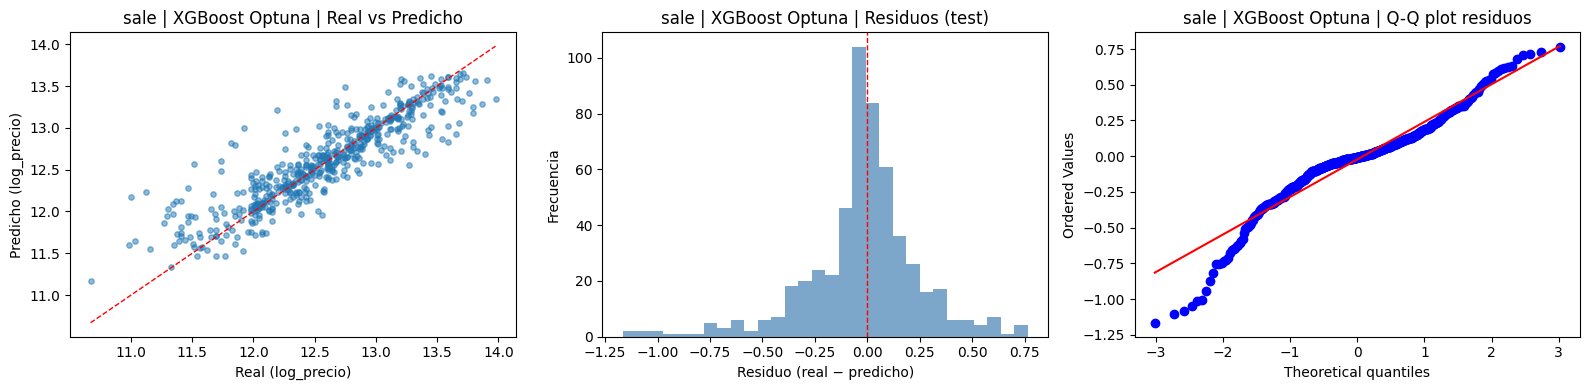

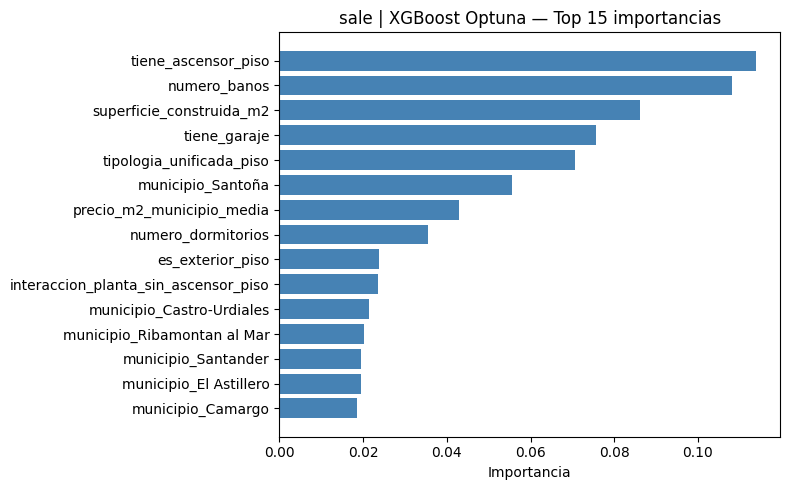


OPTUNA — XGBoost — RENT
Filas: 776


Best trial: 92. Best value: 0.221332: 100%|██████████| 100/100 [01:17<00:00,  1.30it/s]



Mejores parámetros (100 trials):
  n_estimators: 400
  max_depth: 5
  learning_rate: 0.010777459477900125
  subsample: 0.9393397443119648
  colsample_bytree: 0.6455820833987925
  min_child_weight: 5
  reg_lambda: 0.8316634098048754
  reg_alpha: 0.005247094480516109
Mejor CV-RMSE: 0.22133
split     MSE    RMSE     MAE      R2    MAPE
train 0.01531 0.12375 0.09048 0.85373 0.01296
   CV     NaN 0.22133     NaN     NaN     NaN
 test 0.04868 0.22064 0.15786 0.55145 0.02295

  Sobreajuste → ratio RMSE test/train: 1.7829 | delta R2: 0.3023


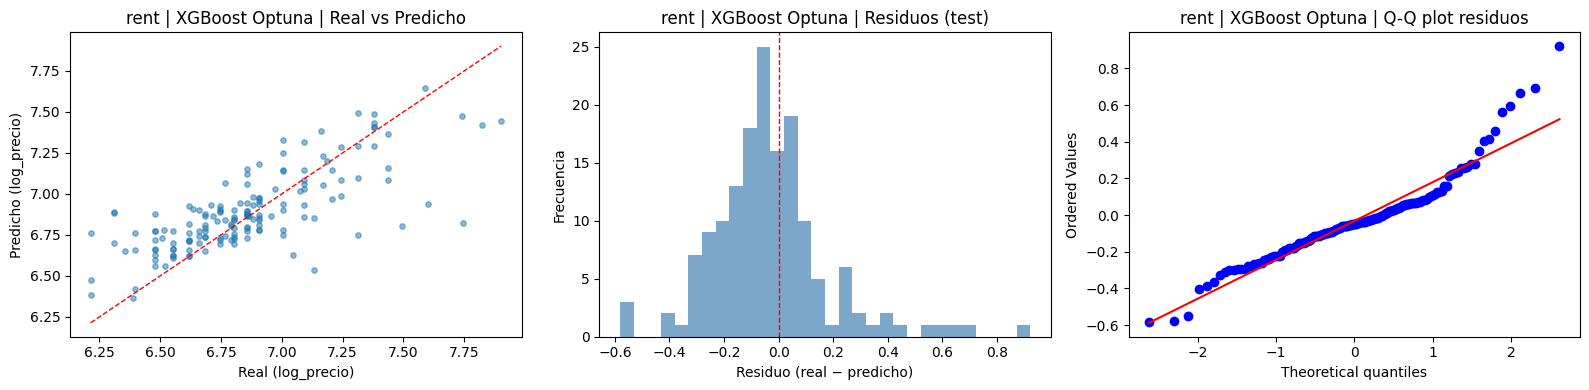

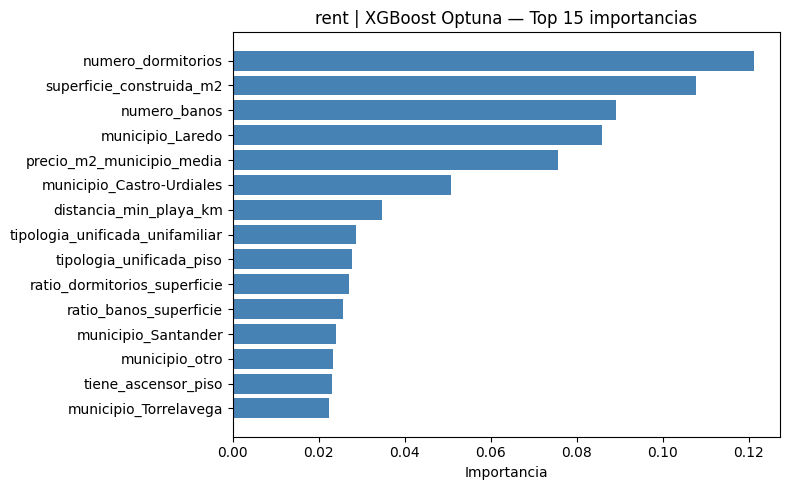


Optimización con Optuna completada.


In [12]:
# ── Optimización Bayesiana — XGBoost ─────────────────────────────────────────
N_TRIALS_OPTUNA = 100

optuna_xgb_results = {}

if not OPTUNA_AVAILABLE:
    print("AVISO: optuna no disponible. Instala con: pip install optuna")
else:
    for dataset_name, dataset_path in DATASETS.items():
        print(f"\n{'='*80}")
        print(f"OPTUNA — XGBoost — {dataset_name.upper()}")
        print(f"{'='*80}")

        df = pd.read_csv(dataset_path)
        df = df[df[TARGET_COL].notna()].copy()
        print(f"Filas: {len(df)}")

        final_muni_cols = sorted([c for c in df.columns if c.startswith("municipio_")])
        all_feature_cols = BASE_FEATURES + final_muni_cols
        X = prepare_X(df, all_feature_cols)
        y = df[TARGET_COL].values

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )
        feature_names = X_train.columns.tolist()

        def objective_xgb(trial):
            params = dict(
                n_estimators=trial.suggest_int("n_estimators", 100, 600, step=100),
                max_depth=trial.suggest_int("max_depth", 3, 8),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                subsample=trial.suggest_float("subsample", 0.6, 1.0),
                colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
                min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
                reg_lambda=trial.suggest_float("reg_lambda", 0.5, 10.0, log=True),
                reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
            )
            model = XGBRegressor(**params, random_state=RANDOM_STATE,
                                 n_jobs=-1, verbosity=0)
            kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
            scores = cross_val_score(
                model, X_train, y_train, cv=kf,
                scoring="neg_root_mean_squared_error", n_jobs=-1
            )
            return float(-scores.mean())

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
        )
        study.optimize(objective_xgb, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

        best_params_clean = study.best_params
        best_cv_rmse = study.best_value

        print(f"\nMejores parámetros ({N_TRIALS_OPTUNA} trials):")
        for k, v in best_params_clean.items():
            print(f"  {k}: {v}")
        print(f"Mejor CV-RMSE: {best_cv_rmse:.5f}")

        xgb_opt = XGBRegressor(
            **best_params_clean, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
        )
        xgb_opt.fit(X_train, y_train)

        m_train = get_metrics(y_train, xgb_opt.predict(X_train))
        m_test  = get_metrics(y_test,  xgb_opt.predict(X_test))

        summary = pd.concat([
            m_train.assign(split="train"),
            pd.DataFrame({"split": ["CV"], "MSE": [None],
                          "RMSE": [round(best_cv_rmse, 5)],
                          "MAE": [None], "R2": [None], "MAPE": [None]}),
            m_test.assign(split="test"),
        ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
        print(summary.to_string(index=False))

        delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
        ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
        print(f"\n  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")

        plot_diagnostics(y_test, xgb_opt.predict(X_test),
                         f"{dataset_name} | XGBoost Optuna")
        plot_feature_importance(
            xgb_opt.feature_importances_, feature_names,
            f"{dataset_name} | XGBoost Optuna — Top 15 importancias"
        )

        optuna_xgb_results[dataset_name] = {
            "model":         xgb_opt,
            "params":        best_params_clean,
            "cv_rmse":       best_cv_rmse,
            "X_train":       X_train,
            "X_test":        X_test,
            "y_train":       y_train,
            "y_test":        y_test,
            "feature_names": feature_names,
            "importances":   pd.Series(xgb_opt.feature_importances_, index=feature_names),
        }

    print("\nOptimización con Optuna completada.")

### Selección de features por importancia

XGBoost calcula la importancia como ganancia acumulada en splits.
Features con importancia baja añaden ruido y ralentizan la predicción.
Ajusta `IMPORTANCE_THRESHOLD` según el gráfico.


SELECCIÓN DE FEATURES — SALE


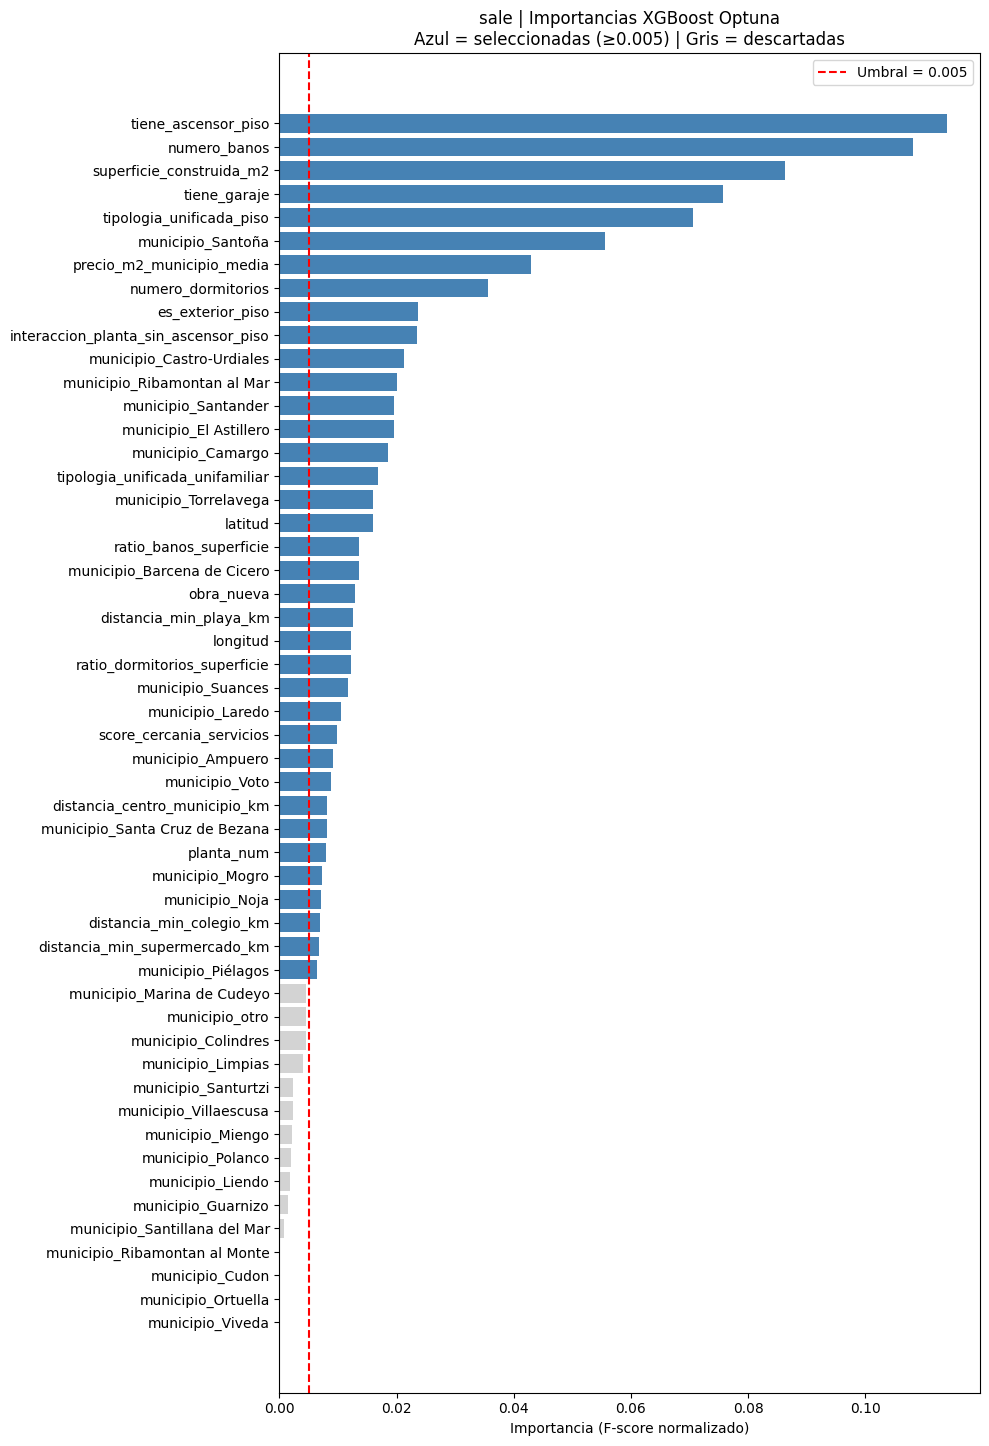

  Seleccionadas (37): ['tiene_ascensor_piso', 'numero_banos', 'superficie_construida_m2', 'tiene_garaje', 'tipologia_unificada_piso', 'municipio_Santoña', 'precio_m2_municipio_media', 'numero_dormitorios', 'es_exterior_piso', 'interaccion_planta_sin_ascensor_piso', 'municipio_Castro-Urdiales', 'municipio_Ribamontan al Mar', 'municipio_Santander', 'municipio_El Astillero', 'municipio_Camargo', 'tipologia_unificada_unifamiliar', 'municipio_Torrelavega', 'latitud', 'ratio_banos_superficie', 'municipio_Barcena de Cicero', 'obra_nueva', 'distancia_min_playa_km', 'longitud', 'ratio_dormitorios_superficie', 'municipio_Suances', 'municipio_Laredo', 'score_cercania_servicios', 'municipio_Ampuero', 'municipio_Voto', 'distancia_centro_municipio_km', 'municipio_Santa Cruz de Bezana', 'planta_num', 'municipio_Mogro', 'municipio_Noja', 'distancia_min_colegio_km', 'distancia_min_supermercado_km', 'municipio_Piélagos']
  Descartadas  (15):  ['municipio_Marina de Cudeyo', 'municipio_otro', 'municipio_C

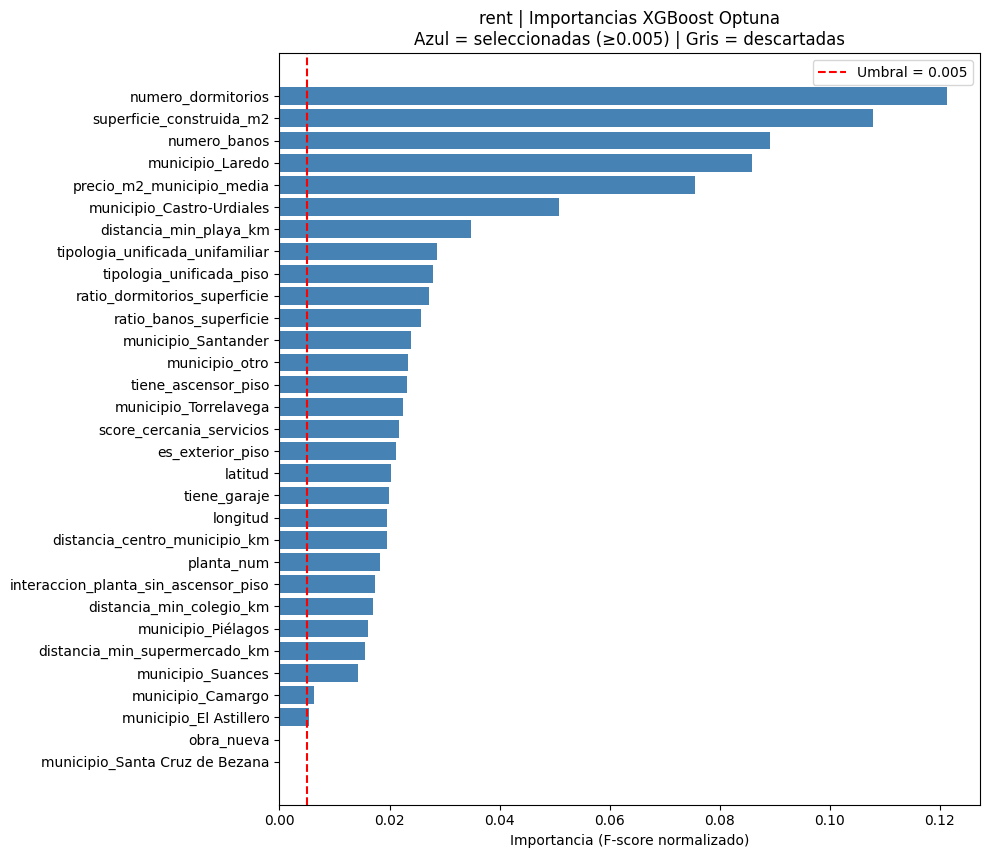

  Seleccionadas (29): ['numero_dormitorios', 'superficie_construida_m2', 'numero_banos', 'municipio_Laredo', 'precio_m2_municipio_media', 'municipio_Castro-Urdiales', 'distancia_min_playa_km', 'tipologia_unificada_unifamiliar', 'tipologia_unificada_piso', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'municipio_Santander', 'municipio_otro', 'tiene_ascensor_piso', 'municipio_Torrelavega', 'score_cercania_servicios', 'es_exterior_piso', 'latitud', 'tiene_garaje', 'longitud', 'distancia_centro_municipio_km', 'planta_num', 'interaccion_planta_sin_ascensor_piso', 'distancia_min_colegio_km', 'municipio_Piélagos', 'distancia_min_supermercado_km', 'municipio_Suances', 'municipio_Camargo', 'municipio_El Astillero']
  Descartadas  (2):  ['obra_nueva', 'municipio_Santa Cruz de Bezana']
                 config  train_RMSE  test_RMSE  train_R2  test_R2
        todas (31 feat)     0.12375    0.22064   0.85373  0.55145
seleccionadas (29 feat)     0.12370    0.22065   0.85383  0.55142


In [13]:
# ── Selección de features por importancia ────────────────────────────────────
IMPORTANCE_THRESHOLD = 0.005

xgb_feature_results = {}

for dataset_name in list(optuna_xgb_results.keys()):
    state = optuna_xgb_results[dataset_name]
    imps  = state["importances"].sort_values(ascending=False)

    print(f"\n{'='*80}")
    print(f"SELECCIÓN DE FEATURES — {dataset_name.upper()}")
    print(f"{'='*80}")

    fig, ax = plt.subplots(figsize=(10, max(6, len(imps) * 0.28)))
    colors_bar = ["steelblue" if v >= IMPORTANCE_THRESHOLD else "lightgray"
                  for v in imps.values[::-1]]
    ax.barh(imps.index[::-1], imps.values[::-1], color=colors_bar)
    ax.axvline(IMPORTANCE_THRESHOLD, color="red", ls="--", lw=1.5,
               label=f"Umbral = {IMPORTANCE_THRESHOLD}")
    ax.set_title(f"{dataset_name} | Importancias XGBoost Optuna\n"
                 f"Azul = seleccionadas (≥{IMPORTANCE_THRESHOLD}) | Gris = descartadas")
    ax.set_xlabel("Importancia (F-score normalizado)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    selected = imps[imps >= IMPORTANCE_THRESHOLD].index.tolist()
    dropped  = imps[imps <  IMPORTANCE_THRESHOLD].index.tolist()
    print(f"  Seleccionadas ({len(selected)}): {selected}")
    print(f"  Descartadas  ({len(dropped)}):  {dropped}")

    X_train_s = state["X_train"][selected]
    X_test_s  = state["X_test"][selected]

    xgb_sel = XGBRegressor(
        **state["params"], random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )
    xgb_sel.fit(X_train_s, state["y_train"])

    m_tr_all = get_metrics(state["y_train"], state["model"].predict(state["X_train"]))
    m_te_all = get_metrics(state["y_test"],  state["model"].predict(state["X_test"]))
    m_tr_sel = get_metrics(state["y_train"], xgb_sel.predict(X_train_s))
    m_te_sel = get_metrics(state["y_test"],  xgb_sel.predict(X_test_s))

    comp = pd.DataFrame([
        {"config": f"todas ({len(state['feature_names'])} feat)",
         "train_RMSE": float(m_tr_all["RMSE"].iloc[0]),
         "test_RMSE":  float(m_te_all["RMSE"].iloc[0]),
         "train_R2":   float(m_tr_all["R2"].iloc[0]),
         "test_R2":    float(m_te_all["R2"].iloc[0])},
        {"config": f"seleccionadas ({len(selected)} feat)",
         "train_RMSE": float(m_tr_sel["RMSE"].iloc[0]),
         "test_RMSE":  float(m_te_sel["RMSE"].iloc[0]),
         "train_R2":   float(m_tr_sel["R2"].iloc[0]),
         "test_R2":    float(m_te_sel["R2"].iloc[0])},
    ])
    print(comp.round(5).to_string(index=False))

    xgb_feature_results[dataset_name] = {
        "features": selected,
        "params":   state["params"],
    }

---
## Modelo Definitivo — XGBoost

Consolida los hiperparámetros óptimos (Optuna) con las features seleccionadas.
Expone `XGB_FEATURES_DEF` y `XGB_PARAMS_DEF` para importar en NB54.


MODELO DEFINITIVO XGB — SALE

Features (37):
  ['tiene_ascensor_piso', 'numero_banos', 'superficie_construida_m2', 'tiene_garaje', 'tipologia_unificada_piso', 'municipio_Santoña', 'precio_m2_municipio_media', 'numero_dormitorios', 'es_exterior_piso', 'interaccion_planta_sin_ascensor_piso', 'municipio_Castro-Urdiales', 'municipio_Ribamontan al Mar', 'municipio_Santander', 'municipio_El Astillero', 'municipio_Camargo', 'tipologia_unificada_unifamiliar', 'municipio_Torrelavega', 'latitud', 'ratio_banos_superficie', 'municipio_Barcena de Cicero', 'obra_nueva', 'distancia_min_playa_km', 'longitud', 'ratio_dormitorios_superficie', 'municipio_Suances', 'municipio_Laredo', 'score_cercania_servicios', 'municipio_Ampuero', 'municipio_Voto', 'distancia_centro_municipio_km', 'municipio_Santa Cruz de Bezana', 'planta_num', 'municipio_Mogro', 'municipio_Noja', 'distancia_min_colegio_km', 'distancia_min_supermercado_km', 'municipio_Piélagos']

Parámetros:
  {'n_estimators': 600, 'max_depth': 8, 'lea

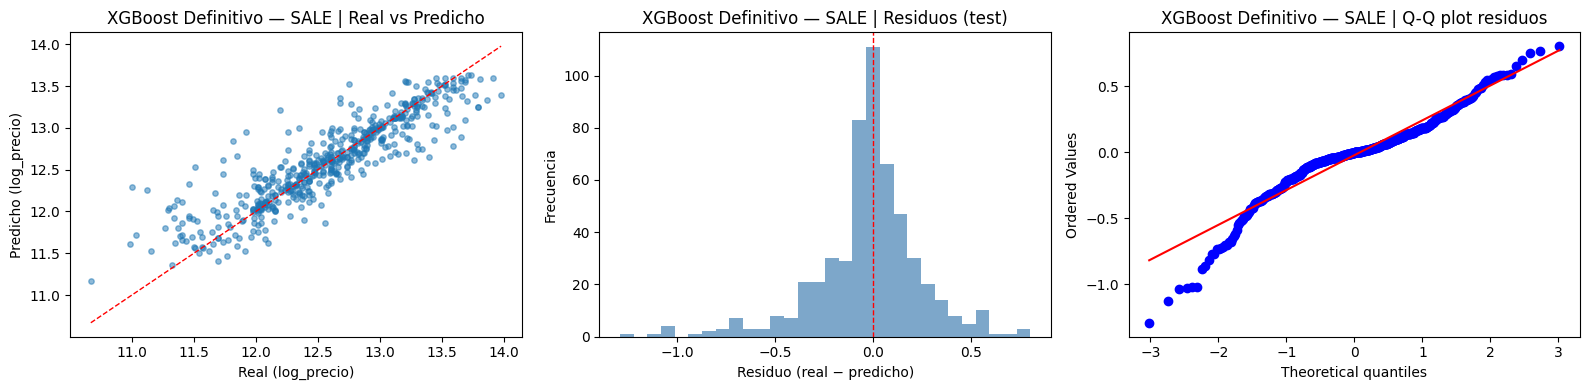

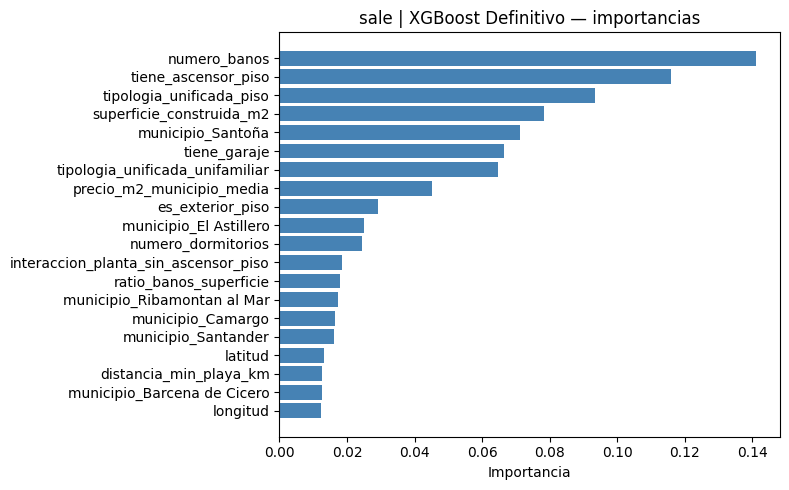


MODELO DEFINITIVO XGB — RENT

Features (29):
  ['numero_dormitorios', 'superficie_construida_m2', 'numero_banos', 'municipio_Laredo', 'precio_m2_municipio_media', 'municipio_Castro-Urdiales', 'distancia_min_playa_km', 'tipologia_unificada_unifamiliar', 'tipologia_unificada_piso', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'municipio_Santander', 'municipio_otro', 'tiene_ascensor_piso', 'municipio_Torrelavega', 'score_cercania_servicios', 'es_exterior_piso', 'latitud', 'tiene_garaje', 'longitud', 'distancia_centro_municipio_km', 'planta_num', 'interaccion_planta_sin_ascensor_piso', 'distancia_min_colegio_km', 'municipio_Piélagos', 'distancia_min_supermercado_km', 'municipio_Suances', 'municipio_Camargo', 'municipio_El Astillero']

Parámetros:
  {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.010777459477900125, 'subsample': 0.9393397443119648, 'colsample_bytree': 0.6455820833987925, 'min_child_weight': 5, 'reg_lambda': 0.8316634098048754, 'reg_alpha': 0.005247094

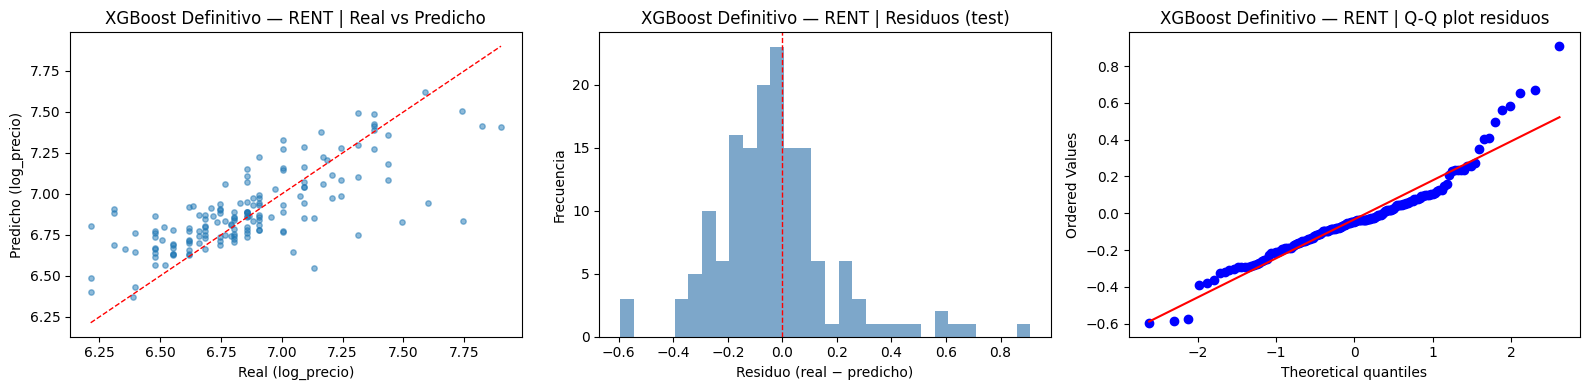

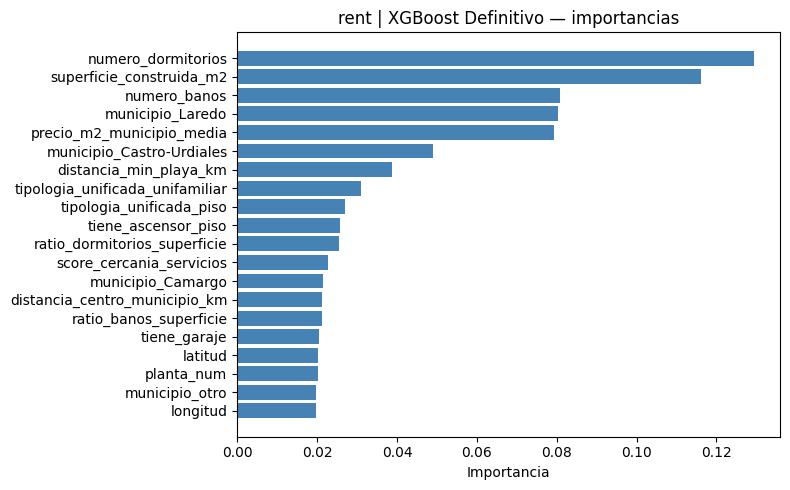


RESUMEN PARA NB54 — copiar XGB_PARAMS y XGB_FEATURES:

  # SALE
  XGB_PARAMS_DEF['sale']   = {'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.019653326029832427, 'subsample': 0.7482390401967269, 'colsample_bytree': 0.6337927911134054, 'min_child_weight': 7, 'reg_lambda': 0.6532280295230286, 'reg_alpha': 0.03929462015394978}
  XGB_FEATURES_DEF['sale'] = ['tiene_ascensor_piso', 'numero_banos', 'superficie_construida_m2', 'tiene_garaje', 'tipologia_unificada_piso', 'municipio_Santoña', 'precio_m2_municipio_media', 'numero_dormitorios', 'es_exterior_piso', 'interaccion_planta_sin_ascensor_piso', 'municipio_Castro-Urdiales', 'municipio_Ribamontan al Mar', 'municipio_Santander', 'municipio_El Astillero', 'municipio_Camargo', 'tipologia_unificada_unifamiliar', 'municipio_Torrelavega', 'latitud', 'ratio_banos_superficie', 'municipio_Barcena de Cicero', 'obra_nueva', 'distancia_min_playa_km', 'longitud', 'ratio_dormitorios_superficie', 'municipio_Suances', 'municipio_Laredo', 'score_ce

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELO DEFINITIVO — XGBoost
# ══════════════════════════════════════════════════════════════════════════════
# Variables exportadas al híbrido (NB54):
#   XGB_FEATURES_DEF  — features definitivas (post-selección)
#   XGB_PARAMS_DEF    — hiperparámetros óptimos (Optuna)

XGB_FEATURES_DEF = {}
XGB_PARAMS_DEF   = {}

for dataset_name, dataset_path in DATASETS.items():
    if dataset_name not in xgb_feature_results:
        print("AVISO: ejecuta primero las celdas de Optuna y selección de features.")
        continue

    feats  = xgb_feature_results[dataset_name]["features"]
    params = {**xgb_feature_results[dataset_name]["params"],
              "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0}

    XGB_FEATURES_DEF[dataset_name] = feats
    XGB_PARAMS_DEF[dataset_name]   = xgb_feature_results[dataset_name]["params"]

    print(f"\n{'='*80}")
    print(f"MODELO DEFINITIVO XGB — {dataset_name.upper()}")
    print(f"{'='*80}")
    print(f"\nFeatures ({len(feats)}):\n  {feats}")
    print(f"\nParámetros:\n  {XGB_PARAMS_DEF[dataset_name]}")

    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()

    X = prepare_X(df, feats)
    y = df[TARGET_COL].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    xgb_def = XGBRegressor(**params)
    xgb_def.fit(X_train, y_train)

    m_train = get_metrics(y_train, xgb_def.predict(X_train))
    m_test  = get_metrics(y_test,  xgb_def.predict(X_test))

    summary = pd.concat([
        m_train.assign(split="train"),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(f"\n{summary.round(5).to_string(index=False)}")

    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"\n  delta R2  train-test:   {delta_r2:+.5f}")
    print(f"  ratio RMSE test/train:  {ratio:.4f}")

    plot_diagnostics(y_test, xgb_def.predict(X_test),
                     f"XGBoost Definitivo — {dataset_name.upper()}")
    plot_feature_importance(
        xgb_def.feature_importances_, feats,
        f"{dataset_name} | XGBoost Definitivo — importancias", top_n=20
    )

print("\n" + "="*80)
print("RESUMEN PARA NB54 — copiar XGB_PARAMS y XGB_FEATURES:")
print("="*80)
for ds in XGB_PARAMS_DEF:
    print(f"\n  # {ds.upper()}")
    print(f"  XGB_PARAMS_DEF[\'{ds}\']   = {XGB_PARAMS_DEF[ds]}")
    print(f"  XGB_FEATURES_DEF[\'{ds}\'] = {XGB_FEATURES_DEF[ds]}")